In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

foldername = '/home/edavenport/analysis/yannai-waves/meridional_structure/'

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+31 # jan, feb, mar (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [3]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-04-01'))

In [5]:
from scipy.signal import butter, sosfiltfilt, detrend

fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/30)*fs #  
lowF = (1/60)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.UVEL.sel(XG=220,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.VVEL.sel(XC=220,method='nearest').sel(YG=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.UVEL.sel(XG=220,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_TAO.VVEL.sel(XC=220,method='nearest').sel(YG=slice(-5,5)).copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

In [6]:
u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")

### Looking at Symmetry

In [8]:
# Separate positive and negative latitudes
v_pos = v_prime.sel(YG=v_prime.YG > 0)
v_neg = v_prime.sel(YG=v_prime.YG < 0)

# Make latitudes match by flipping southern hemisphere
v_neg = v_neg.assign_coords(YG=-v_neg.YG)
v_neg = v_neg.sortby('YG')

v_pos = v_pos.sortby('YG')

In [10]:
v_sym = 0.5 * (v_pos + v_neg) # symmetric component
v_anti = 0.5 * (v_pos - v_neg) # antisymmetric component

var_sym = (v_sym ** 2).mean('time')
var_anti = (v_anti ** 2).mean('time')

frac_sym = var_sym / (var_sym + var_anti)
frac_anti = var_anti / (var_sym + var_anti)

var_anti_plot = var_anti.where(var_anti > 0)
var_sym_plot = var_sym.where(var_sym > 0)

# optionally do this across a box of multiple longitudes 
# var_sym_total = (v_sym ** 2).mean(dim=('time','XC','Z'))
# var_anti_total = (v_anti ** 2).mean(dim=('time','XC','Z'))

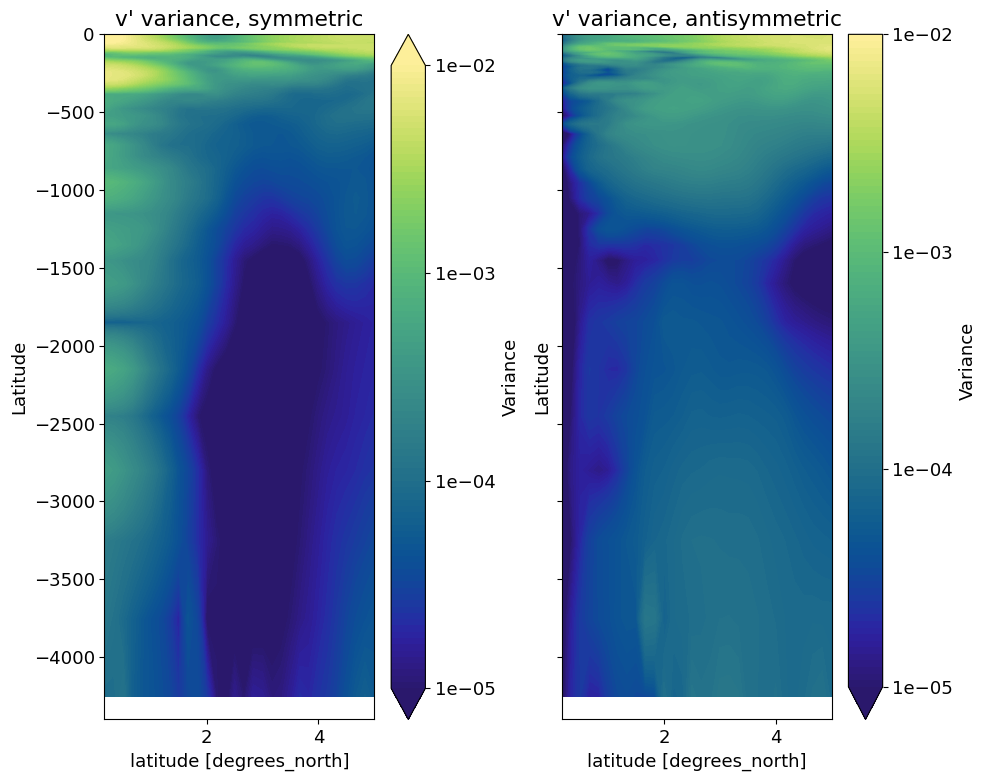

In [35]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter

levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('v\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('v\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'v_variance_sym_anti.png', dpi=300)

In [32]:
# Separate positive and negative latitudes
u_pos = u_prime.sel(YC=u_prime.YC > 0)
u_neg = u_prime.sel(YC=u_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
u_neg = u_neg.assign_coords(YC=-u_neg.YC)
u_neg = u_neg.sortby('YC')

u_pos = u_pos.sortby('YC')

In [33]:
u_sym = 0.5 * (u_pos + u_neg) # symmetric component
u_anti = 0.5 * (u_pos - u_neg) # antisymmetric component

var_u_sym = (u_sym ** 2).mean('time')
var_u_anti = (u_anti ** 2).mean('time')

frac_sym = var_u_sym / (var_u_sym + var_u_anti)
frac_anti = var_u_anti / (var_u_sym + var_u_anti)

var_u_anti_plot = var_u_anti.where(var_u_anti > 0)
var_u_sym_plot = var_u_sym.where(var_u_sym > 0)

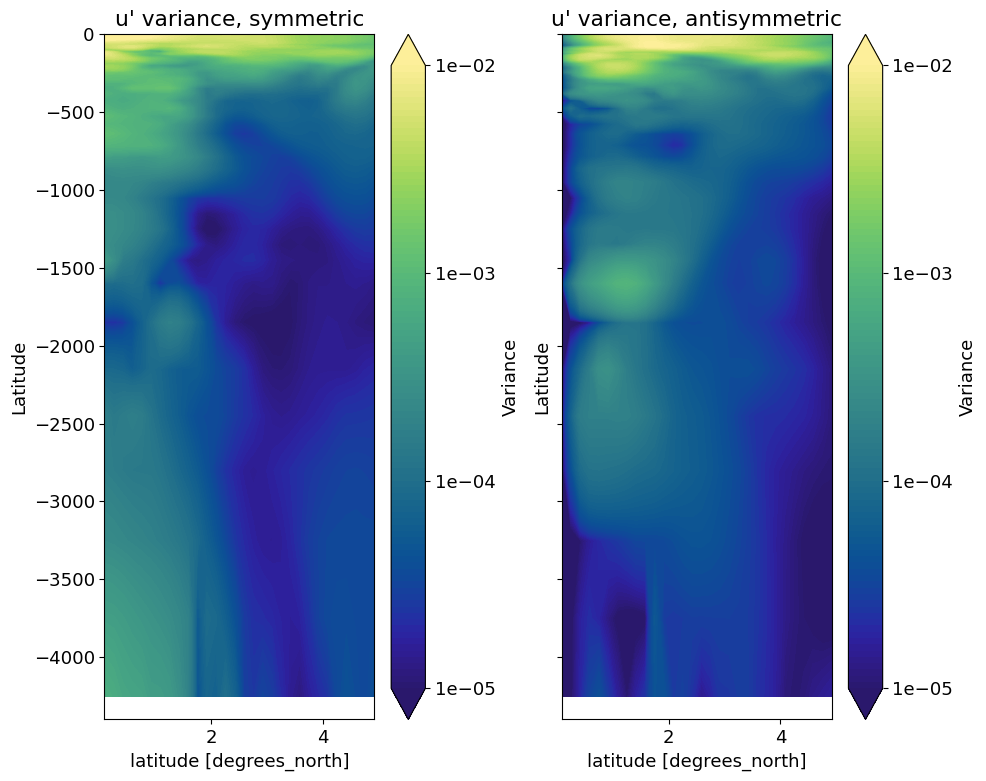

In [36]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_u_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('u\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_u_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('u\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'u_variance_sym_anti.png', dpi=300)

### SSH 

In [37]:
etan_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.ETAN.sel(XC=220,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.ETAN.sel(XC=220,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = etan_bandpass
etan_bandpass = temp

In [38]:
etan_prime = etan_bandpass - etan_bandpass.mean(dim="time")
# Separate positive and negative latitudes
etan_pos = etan_prime.sel(YC=etan_prime.YC > 0)
etan_neg = etan_prime.sel(YC=etan_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
etan_neg = etan_neg.assign_coords(YC=-etan_neg.YC)
etan_neg = etan_neg.sortby('YC')

etan_pos = etan_pos.sortby('YC')

In [39]:
etan_sym = 0.5 * (etan_pos + etan_neg) # symmetric component
etan_anti = 0.5 * (etan_pos - etan_neg) # antisymmetric component

var_etan_sym = (etan_sym ** 2).mean('time')
var_etan_anti = (etan_anti ** 2).mean('time')

frac_sym = var_etan_sym / (var_etan_sym + var_etan_anti)
frac_anti = var_etan_anti / (var_etan_sym + var_etan_anti)

var_etan_anti_plot = var_etan_anti.where(var_etan_anti > 0)
var_etan_sym_plot = var_etan_sym.where(var_etan_sym > 0)

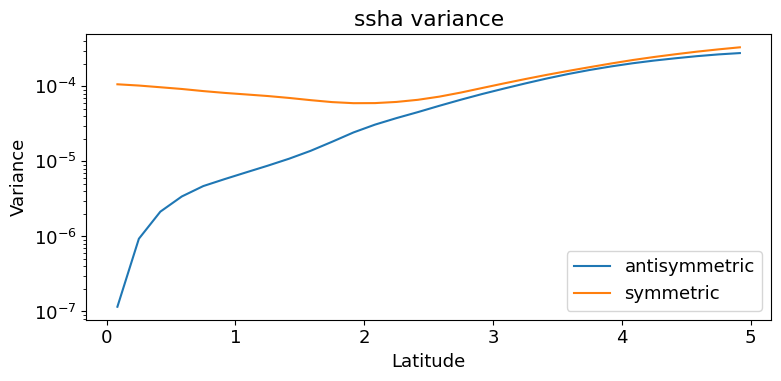

In [42]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(8,4))
var_etan_anti_plot.plot(ax=ax,x='YC',label='antisymmetric')
var_etan_sym_plot.plot(ax=ax,x='YC',label='symmetric')
ax.semilogy()
ax.set_title('ssha variance')
ax.set_ylabel('Variance')
ax.set_xlabel('Latitude')
ax.legend()
plt.tight_layout()
fig.savefig(foldername + 'etan_variance_sym_anti.png', dpi=300)

### Repeat for 110W

In [43]:
uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.UVEL.sel(XG=250,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.VVEL.sel(XC=250,method='nearest').sel(YG=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.UVEL.sel(XG=250,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_TAO.VVEL.sel(XC=250,method='nearest').sel(YG=slice(-5,5)).copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")

In [45]:
# Separate positive and negative latitudes
v_pos = v_prime.sel(YG=v_prime.YG > 0)
v_neg = v_prime.sel(YG=v_prime.YG < 0)

# Make latitudes match by flipping southern hemisphere
v_neg = v_neg.assign_coords(YG=-v_neg.YG)
v_neg = v_neg.sortby('YG')

v_pos = v_pos.sortby('YG')

v_sym = 0.5 * (v_pos + v_neg) # symmetric component
v_anti = 0.5 * (v_pos - v_neg) # antisymmetric component

var_sym = (v_sym ** 2).mean('time')
var_anti = (v_anti ** 2).mean('time')

frac_sym = var_sym / (var_sym + var_anti)
frac_anti = var_anti / (var_sym + var_anti)

var_anti_plot = var_anti.where(var_anti > 0)
var_sym_plot = var_sym.where(var_sym > 0)

In [46]:
# Separate positive and negative latitudes
u_pos = u_prime.sel(YC=u_prime.YC > 0)
u_neg = u_prime.sel(YC=u_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
u_neg = u_neg.assign_coords(YC=-u_neg.YC)
u_neg = u_neg.sortby('YC')

u_pos = u_pos.sortby('YC')

u_sym = 0.5 * (u_pos + u_neg) # symmetric component
u_anti = 0.5 * (u_pos - u_neg) # antisymmetric component

var_u_sym = (u_sym ** 2).mean('time')
var_u_anti = (u_anti ** 2).mean('time')

frac_sym = var_u_sym / (var_u_sym + var_u_anti)
frac_anti = var_u_anti / (var_u_sym + var_u_anti)

var_u_anti_plot = var_u_anti.where(var_u_anti > 0)
var_u_sym_plot = var_u_sym.where(var_u_sym > 0)

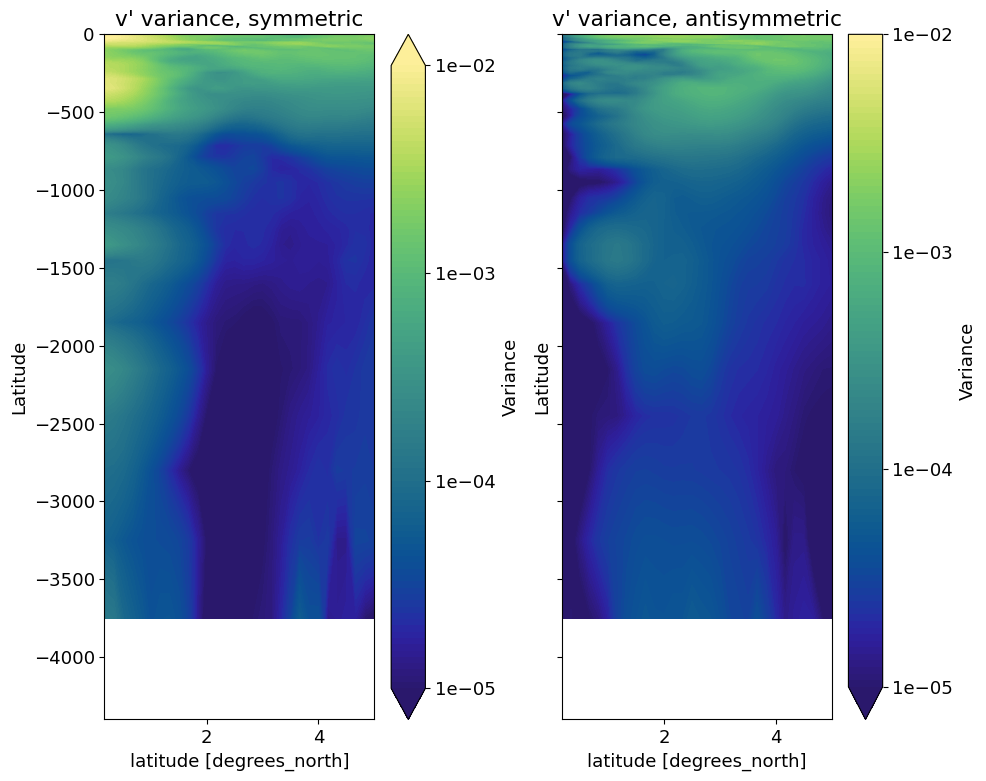

In [47]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('v\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('v\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'v_variance_sym_anti_110.png', dpi=300)

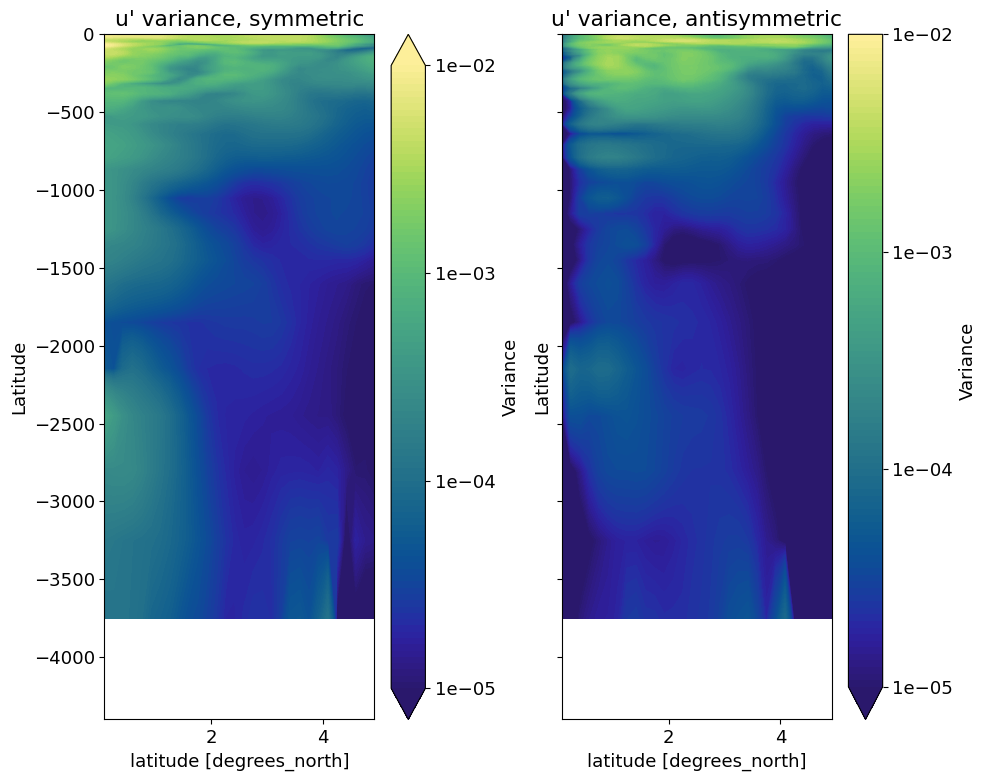

In [48]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_u_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('u\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_u_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('u\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'u_variance_sym_anti_110.png', dpi=300)

In [50]:
etan_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.ETAN.sel(XC=250,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.ETAN.sel(XC=250,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = etan_bandpass
etan_bandpass = temp

etan_prime = etan_bandpass - etan_bandpass.mean(dim="time")
# Separate positive and negative latitudes
etan_pos = etan_prime.sel(YC=etan_prime.YC > 0)
etan_neg = etan_prime.sel(YC=etan_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
etan_neg = etan_neg.assign_coords(YC=-etan_neg.YC)
etan_neg = etan_neg.sortby('YC')

etan_pos = etan_pos.sortby('YC')

etan_sym = 0.5 * (etan_pos + etan_neg) # symmetric component
etan_anti = 0.5 * (etan_pos - etan_neg) # antisymmetric component

var_etan_sym = (etan_sym ** 2).mean('time')
var_etan_anti = (etan_anti ** 2).mean('time')

frac_sym = var_etan_sym / (var_etan_sym + var_etan_anti)
frac_anti = var_etan_anti / (var_etan_sym + var_etan_anti)

var_etan_anti_plot = var_etan_anti.where(var_etan_anti > 0)
var_etan_sym_plot = var_etan_sym.where(var_etan_sym > 0)

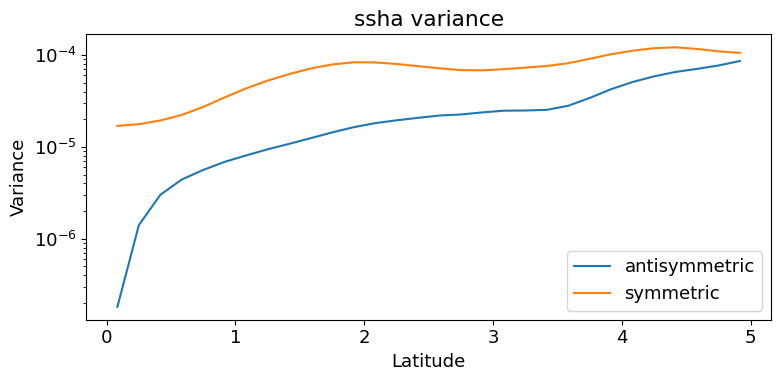

In [51]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(8,4))
var_etan_anti_plot.plot(ax=ax,x='YC',label='antisymmetric')
var_etan_sym_plot.plot(ax=ax,x='YC',label='symmetric')
ax.semilogy()
ax.set_title('ssha variance')
ax.set_ylabel('Variance')
ax.set_xlabel('Latitude')
ax.legend()
plt.tight_layout()
fig.savefig(foldername + 'etan_variance_sym_anti_110.png', dpi=300)

### 170 

In [53]:
uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.UVEL.sel(XG=190,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.VVEL.sel(XC=190,method='nearest').sel(YG=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.UVEL.sel(XG=190,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_TAO.VVEL.sel(XC=190,method='nearest').sel(YG=slice(-5,5)).copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")

In [54]:
# Separate positive and negative latitudes
v_pos = v_prime.sel(YG=v_prime.YG > 0)
v_neg = v_prime.sel(YG=v_prime.YG < 0)

# Make latitudes match by flipping southern hemisphere
v_neg = v_neg.assign_coords(YG=-v_neg.YG)
v_neg = v_neg.sortby('YG')

v_pos = v_pos.sortby('YG')

v_sym = 0.5 * (v_pos + v_neg) # symmetric component
v_anti = 0.5 * (v_pos - v_neg) # antisymmetric component

var_sym = (v_sym ** 2).mean('time')
var_anti = (v_anti ** 2).mean('time')

frac_sym = var_sym / (var_sym + var_anti)
frac_anti = var_anti / (var_sym + var_anti)

var_anti_plot = var_anti.where(var_anti > 0)
var_sym_plot = var_sym.where(var_sym > 0)

In [55]:
# Separate positive and negative latitudes
u_pos = u_prime.sel(YC=u_prime.YC > 0)
u_neg = u_prime.sel(YC=u_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
u_neg = u_neg.assign_coords(YC=-u_neg.YC)
u_neg = u_neg.sortby('YC')

u_pos = u_pos.sortby('YC')

u_sym = 0.5 * (u_pos + u_neg) # symmetric component
u_anti = 0.5 * (u_pos - u_neg) # antisymmetric component

var_u_sym = (u_sym ** 2).mean('time')
var_u_anti = (u_anti ** 2).mean('time')

frac_sym = var_u_sym / (var_u_sym + var_u_anti)
frac_anti = var_u_anti / (var_u_sym + var_u_anti)

var_u_anti_plot = var_u_anti.where(var_u_anti > 0)
var_u_sym_plot = var_u_sym.where(var_u_sym > 0)

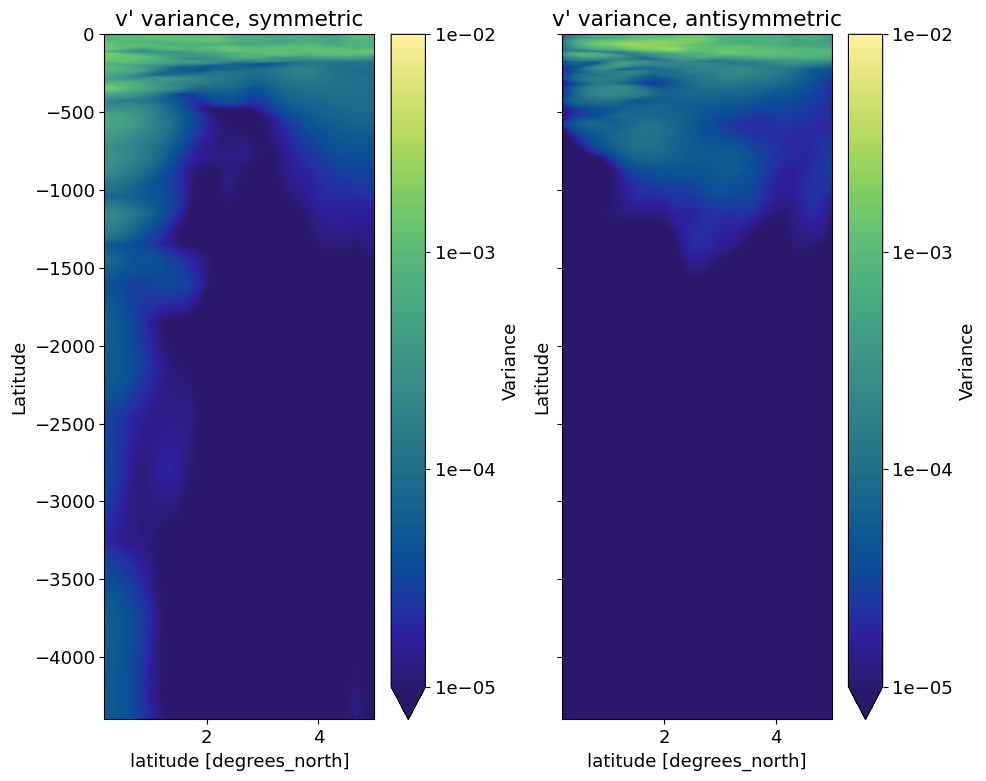

In [56]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('v\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('v\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'v_variance_sym_anti_170.png', dpi=300)

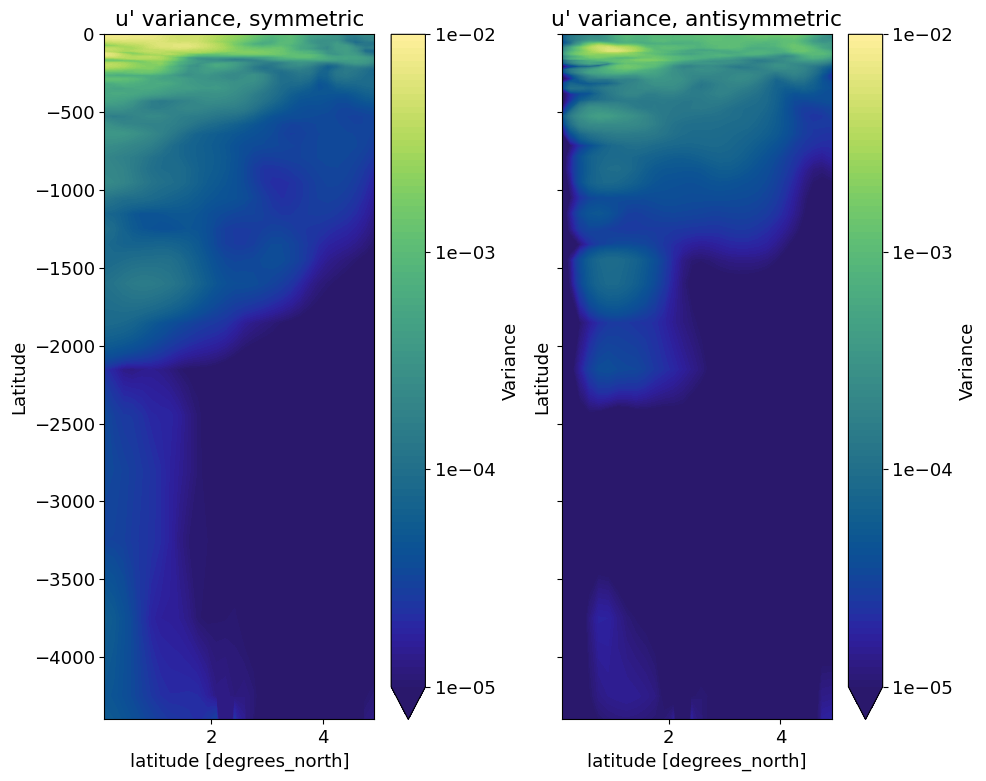

In [57]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(10,8),ncols=2,sharey=True)
cf = var_u_sym_plot.plot.contourf(levels=levels, ax=ax[0], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[0].set_title('u\' variance, symmetric')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-4400,0)

cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

cf = var_u_anti_plot.plot.contourf(levels=levels, ax=ax[1], y='Z', cmap=cmo.haline, norm=LogNorm(vmin=1e-5, vmax=1e-2), cbar_kwargs={'label': 'Variance'})
ax[1].set_title('u\' variance, antisymmetric')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylabel('Latitude')
ax[1].set_ylim(-4400,0)
cbar = cf.colorbar
cbar.locator = LogLocator(base=10)          # ticks at 10^-5, 10^-4, ...
cbar.formatter = LogFormatter(base=10)      # format as 10^{-x}
cbar.update_ticks()

plt.tight_layout()
fig.savefig(foldername + 'u_variance_sym_anti_170.png', dpi=300)

In [60]:
etan_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.ETAN.sel(XC=190,method='nearest').sel(YC=slice(-5,5)),axis=0), axis=0)

temp = ds_tpose_TAO.ETAN.sel(XC=190,method='nearest').sel(YC=slice(-5,5)).copy(deep=True)
temp.data = etan_bandpass
etan_bandpass = temp

etan_prime = etan_bandpass - etan_bandpass.mean(dim="time")
# Separate positive and negative latitudes
etan_pos = etan_prime.sel(YC=etan_prime.YC > 0)
etan_neg = etan_prime.sel(YC=etan_prime.YC < 0)

# Make latitudes match by flipping southern hemisphere
etan_neg = etan_neg.assign_coords(YC=-etan_neg.YC)
etan_neg = etan_neg.sortby('YC')

etan_pos = etan_pos.sortby('YC')

etan_sym = 0.5 * (etan_pos + etan_neg) # symmetric component
etan_anti = 0.5 * (etan_pos - etan_neg) # antisymmetric component

var_etan_sym = (etan_sym ** 2).mean('time')
var_etan_anti = (etan_anti ** 2).mean('time')

frac_sym = var_etan_sym / (var_etan_sym + var_etan_anti)
frac_anti = var_etan_anti / (var_etan_sym + var_etan_anti)

var_etan_anti_plot = var_etan_anti.where(var_etan_anti > 0)
var_etan_sym_plot = var_etan_sym.where(var_etan_sym > 0)

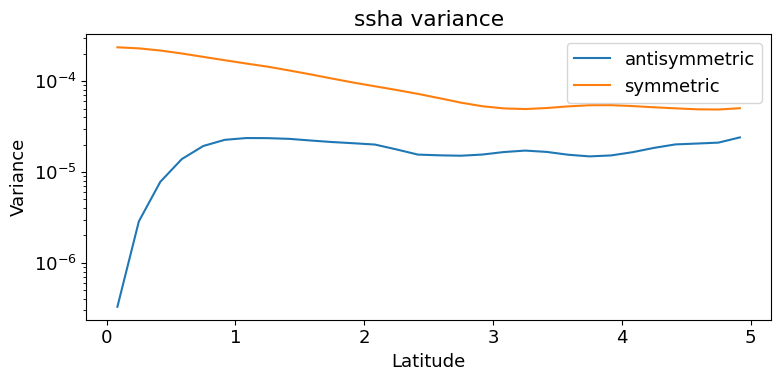

In [61]:
levels = np.logspace(-5, -2, 100)

fig, ax = plt.subplots(figsize=(8,4))
var_etan_anti_plot.plot(ax=ax,x='YC',label='antisymmetric')
var_etan_sym_plot.plot(ax=ax,x='YC',label='symmetric')
ax.semilogy()
ax.set_title('ssha variance')
ax.set_ylabel('Variance')
ax.set_xlabel('Latitude')
ax.legend()
plt.tight_layout()
fig.savefig(foldername + 'etan_variance_sym_anti_170.png', dpi=300)

In [ ]:
client.shutdown()
cluster.close()
client.close()